In [55]:
import numpy as np
import pandas as pd

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
from google.colab import files
uploaded = files.upload()

Saving cs_students.csv to cs_students.csv


In [58]:
data = pd.read_csv("/content/cs_students.csv")

In [59]:
#  FEATURES & TARGET
X = data.drop("Future Career", axis=1)
y = data["Future Career"]

In [60]:
# 3. ENCODE LABELS
le = LabelEncoder()
y = le.fit_transform(y)

In [61]:
# Drop 'Student ID' and 'Name' columns, as they are non-numeric identifiers
# Re-initialize X as a DataFrame to ensure .drop() can be called correctly if the cell is re-executed.
X = data.drop("Future Career", axis=1)
X = X.drop(columns=['Student ID', 'Name'])

# Identify remaining non-numeric (object type) columns
object_columns = X.select_dtypes(include='object').columns

# Apply LabelEncoder to each of the remaining object columns
for col in object_columns:
    le_X = LabelEncoder()
    X[col] = le_X.fit_transform(X[col])

# Now, all columns in X should be numeric, so StandardScaler can be applied
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [62]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
# BUILD ANN MODEL

model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
# COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [65]:
#train model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1, validation_data=(X_test, y_test))

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0694 - loss: 3.4617 - val_accuracy: 0.1667 - val_loss: 3.2278
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1528 - loss: 3.2695 - val_accuracy: 0.1944 - val_loss: 3.0599
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2083 - loss: 3.0951 - val_accuracy: 0.1667 - val_loss: 2.9018
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2917 - loss: 2.8980 - val_accuracy: 0.1944 - val_loss: 2.7453
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3403 - loss: 2.6961 - val_accuracy: 0.2778 - val_loss: 2.5930
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3750 - loss: 2.4881 - val_accuracy: 0.3056 - val_loss: 2.4481
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4444 - loss: 2.2799 - val_accuracy: 0.3056 - val_loss: 2.3453
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4931 - loss: 2.0939 - val_accuracy: 0.3056 - val_loss

In [66]:
# PREDICTION
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [67]:
# Convert numbers → career names
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

In [68]:
print("\n=== SAMPLE PREDICTIONS ===")
for i in range(5):
    print("Predicted:", y_pred_labels[i])
    print("Actual   :", y_test_labels[i])
    print("------")



=== SAMPLE PREDICTIONS ===
Predicted: Mobile App Developer
Actual   : Mobile App Developer
------
Predicted: Software Engineer
Actual   : Mobile App Developer
------
Predicted: Database Administrator
Actual   : Mobile App Developer
------
Predicted: Database Administrator
Actual   : Database Administrator
------
Predicted: AI Researcher
Actual   : AI Researcher
------


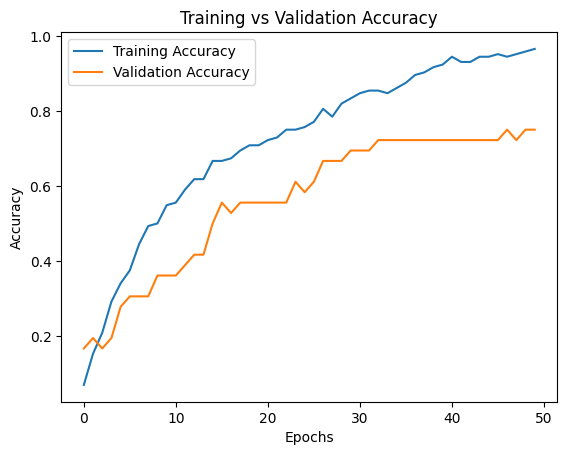

In [69]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [70]:
# 12. TEST CASES (NEW STUDENTS)
# ---------------------------------
print("\n=== TEST CASES ===")


test_students = np.array([

    [1, 21, 3.5, 0, 1, 0, 1, 0, 1], # Student 1 (example preprocessed values)
    [0, 20, 3.2, 1, 0, 1, 0, 1, 0], # Student 2 (example preprocessed values)
    [1, 22, 3.8, 1, 1, 1, 1, 0, 0]  # Student 3 (example preprocessed values)
])


actual_feature_names = data.drop(columns=['Student ID', 'Name', 'Future Career']).columns.tolist()


test_students_df = pd.DataFrame(test_students, columns=actual_feature_names)

# Scale input
test_students_scaled = scaler.transform(test_students_df)

# Predict
predictions = model.predict(test_students_scaled)
predicted_classes = np.argmax(predictions, axis=1)

# Convert to career names
predicted_careers = le.inverse_transform(predicted_classes)

# Output results
for i, career in enumerate(predicted_careers):
    print(f"Student {i+1} Recommended Career: {career}")


=== TEST CASES ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Student 1 Recommended Career: Graphics Programmer
Student 2 Recommended Career: Cloud Solutions Architect
Student 3 Recommended Career: Cloud Solutions Architect


In [71]:
print("\n=== MODEL EVALUATION ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



=== MODEL EVALUATION ===
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           3       0.83      1.00      0.91         5
           5       1.00      1.00      1.00         1
           6       0.00      0.00      0.00         0
           7       1.00      1.00      1.00         1
           8       0.50      1.00      0.67         2
          11       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       0.50      1.00      0.67         1
          16       1.00      1.00      1.00         1
          17       0.00      0.00      0.00         1
          18       0.67      1.00      0.80         2
          19       0.00      0.00      0.00         1
          20       1.00      0.50      0.67         2
          22       1.00      0.70      0.82        10
          25    